# Against the line, 2026: who is perfect?

**The question (Marc, 2026-09-26):**

> Can you add a notebook, cfdb_ats_analysis, use the conn and plots .py files as inputs, augment as
> nessesary) and build an analysis of what teams are perfect on the season for covering: covering
> their side of the spread, missing their side of the spread, below O/U, over O/U. tabular in form,
> with supporting sections that shows each teams games up to (and including) this week, with the
> results and performance ATS. Basically, I want to see teams that are consistently over or
> underperforming in the different aspects of the betting lines.

**His answers:** season **2026**, **FBS teams only**, judged on the **closing line only**, **perfect
records only** (no ranked leaderboard).

## How to read it

| term | meaning | example |
|---|---|---|
| **spread** | the points a team is given (+) or has to give (−) | Team −7 must win by more than 7 |
| **ATS** (against the spread) | the result once the spread is added to the score | win 24–20 as a −7 favourite = **failed to cover** |
| **ATS margin** | `margin + team's spread`; positive = covered, by that many points | 24–20 at −7 → 4 − 7 = **−3** |
| **closing line** | the last number offered before kickoff — the market's final opinion | |
| **over / under** | the two teams' combined points against the posted total | 31 + 27 = 58 vs a 51.5 total → **over** |
| **push** | landing exactly on the number — neither a cover nor a miss, neither over nor under | win by 7 at −7 |

**"This week" means every game completed when the notebook ran.** Week 4 is played mostly on
Saturday, so a run on Saturday morning holds only its Thursday and Friday games. **Re-running the
notebook changes the answer** — the header output below says exactly what it covered.

**Where the numbers come from:** `serving.srv_game_team`, one row per team per game, on the
transform warehouse. It already carries the team-side closing spread (`spread_final`), the ATS
margin and the cover verdict. It carries the closing total (`total_final`) but **no over/under
verdict**, so that one is derived here and then checked against `srv_game.over_met`, the game-level
verdict the site uses.

## Setup

In [1]:
# Both helpers live beside this notebook.
import cfdb_conn as cf
import cfdb_plots as viz

import pandas as pd
from IPython.display import HTML, Markdown, display

viz.set_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 400)
pd.set_option("display.width", 200)

# Every colour is stated (text AND background), so the tables read the same in a light theme,
# a dark theme and on a black-and-white printer.
display(HTML("""
<style>
table.dataframe { border-collapse: collapse !important; border: 1px solid #8e99a6 !important;
    background-color: #ffffff !important; color: #1a1a1a !important; font-size: 12px !important; }
table.dataframe td, table.dataframe th { border: 1px solid #c3cbd5 !important;
    padding: 4px 8px !important; text-align: left !important; }
table.dataframe thead th { background-color: #2f4156 !important; color: #ffffff !important;
    font-weight: 600 !important; border-color: #2f4156 !important; position: sticky; top: 0; z-index: 2; }
table.dataframe tbody th { background-color: #eceff4 !important; color: #1a1a1a !important;
    font-weight: 600 !important; }
table.dataframe tbody td { background-color: #ffffff !important; color: #1a1a1a !important; }
table.dataframe tbody tr:nth-child(even) td { background-color: #f6f8fa !important; }
table.dataframe tbody tr:hover td { background-color: #fff6d5 !important; }
</style>
"""))

In [2]:
# What am I connected to, and how old is the data?
cf.check()

repo root : /Users/marcalexander/projects/ai_orchestrator_claude/ncaa_football/wt-c
backend   : warehouse  (droplet TRANSFORM warehouse -- what dbt has BUILT)
target    : cfdb@127.0.0.1:15433/cfdb
schema    : serving


connected : yes -- 37 srv_ views visible


data as of: 2026-09-26 12:00 UTC (0d 2h ago), newest of 6 domains


## 1 · The games

Every **completed** 2026 regular-season game played by an **FBS** team. The filter is on the
TEAM's classification, so an FBS team's game against an FCS opponent stays in (it has a line);
the FCS side of that game does not get a row of its own here.

In [3]:
SEASON = 2026

games = cf.q(f"""
    select g.team, g.conference, g.week, g.game_date, g.game_id,
           g.opponent, g.opponent_classification, g.is_home, g.is_neutral_site,
           g.points_for, g.points_against, g.margin, g.result,
           g.spread_final, g.ats_margin_final, g.covered_final, g.total_final
    from {cf.t("srv_game_team")} g
    where g.season = :season
      and g.classification = 'fbs'
      and g.is_completed
""", {"season": SEASON}, limit=None)

games["site"] = games["is_neutral_site"].map({True: "neutral"}).fillna(
    games["is_home"].map({True: "home", False: "away"}))
games["combined_points"] = games["points_for"] + games["points_against"]
games = games.sort_values(["team", "week", "game_date"]).reset_index(drop=True)

print(f"season            : {SEASON}")
print(f"latest week       : {games['week'].max()}")
print(f"latest game date  : {games['game_date'].max()}")
print(f"team-games        : {len(games):,}   ({games['game_id'].nunique():,} games, {games['team'].nunique()} FBS teams)")
print("team-games by week:", games.groupby("week").size().to_dict())

season            : 2026
latest week       : 4
latest game date  : 2026-09-25
team-games        : 428   (266 games, 138 FBS teams)
team-games by week: {1: 150, 2: 135, 3: 132, 4: 11}


### Which line was used

`spread_final` is `coalesce(spread_at_close, spread_current)` — the closing line where one was
captured, **the current line otherwise**. `marts.fct_game_market` records whether a close exists and
how it was obtained (`observed_before_kickoff` = cfdb sampled it while the market was live), so the
fallback can be counted rather than assumed.

In [4]:
basis = cf.q(f"""
    select m.game_id,
           m.spread_at_close is null  as spread_fell_back_to_current,
           m.total_at_close  is null  as total_fell_back_to_current,
           m.spread_at_close_basis, m.total_at_close_basis, m.spread_at_close_provider
    from {cf.t("fct_game_market", cf.MARTS_SCHEMA)} m
    where m.game_id in (select distinct game_id from {cf.t("srv_game_team")}
                        where season = :season and classification = 'fbs' and is_completed)
""", {"season": SEASON}, limit=None)

graded_ids = games.loc[games["spread_final"].notna() | games["total_final"].notna(), "game_id"].unique()
b = basis[basis["game_id"].isin(graded_ids)]
print(f"graded games                          : {len(graded_ids)}")
print(f"  spread fell back to the current line: {int(b['spread_fell_back_to_current'].sum())}")
print(f"  total fell back to the current line : {int(b['total_fell_back_to_current'].sum())}")
print(f"  games with no market row at all     : {len(set(graded_ids) - set(basis['game_id']))}")
display(b.groupby(["spread_at_close_basis", "total_at_close_basis"], dropna=False).size()
         .rename("games").reset_index())
display(b["spread_at_close_provider"].value_counts(dropna=False).rename("games").to_frame())

graded games                          : 266
  spread fell back to the current line: 0
  total fell back to the current line : 0
  games with no market row at all     : 0


,spread_at_close_basis,total_at_close_basis,games
0,observed_before_kickoff,observed_before_kickoff,266


,games
spread_at_close_provider,
bovada,257
draftkings,9


### Over / under — derived, then checked

`over` if combined points beat `total_final`, `under` if they fall short, `push` if exactly on it.
`total_margin = combined points − total_final` (positive = over, by that many points).

**The check:** `srv_game.over_met` is the site's own game-level verdict against the closing total.
Every derived result must agree with it, row for row. A disagreement stops the notebook here.

In [5]:
def ou_result(combined, total):
    """over / under / push, or None where there is no total."""
    if pd.isna(total):
        return None
    return "over" if combined > total else "under" if combined < total else "push"


games["ou_result"] = [ou_result(c, t) for c, t in zip(games["combined_points"], games["total_final"])]
games["total_margin"] = games["combined_points"] - games["total_final"]

site = cf.q(f"""select game_id, over_met from {cf.t("srv_game")} where season = :season""",
            {"season": SEASON}, limit=None)
check = games.merge(site, on="game_id", how="left")
check["site_verdict"] = check["over_met"].map({"yes": "over", "no": "under", "push": "push"})
disagree = check[check["ou_result"].fillna("-") != check["site_verdict"].fillna("-")]
print(f"rows compared: {len(check)} · disagreements with srv_game.over_met: {len(disagree)}")
assert disagree.empty, disagree[["team", "week", "combined_points", "total_final", "ou_result", "over_met"]]

rows compared: 428 · disagreements with srv_game.over_met: 0


### The ATS sign — checked on every row

`covered_final` comes from the warehouse. Recompute it here from `margin + spread_final` (team side)
and require agreement everywhere. One **away** row is printed so the arithmetic can be read by eye.

In [6]:
recomputed_margin = games["margin"] + games["spread_final"]
recomputed = recomputed_margin.map(lambda m: None if pd.isna(m) else "yes" if m > 0 else "no" if m < 0 else "push")
bad = games[(recomputed.fillna("-") != games["covered_final"].fillna("-"))
            | ((recomputed_margin - games["ats_margin_final"]).abs() > 1e-9)]
print(f"rows where covered_final or ats_margin_final disagree with margin + spread: {len(bad)}")
assert bad.empty, bad

away = games[(games["site"] == "away") & (games["spread_final"] < 0)].iloc[0]
print(f"\nAway row: {away['team']} at {away['opponent']}, week {away['week']}")
print(f"  score {away['points_for']}-{away['points_against']} → margin {away['margin']:+d}")
print(f"  team-side spread {away['spread_final']:+g}  (a road favourite)")
print(f"  margin + spread = {away['margin']:+d} + ({away['spread_final']:+g}) = {away['margin'] + away['spread_final']:+g}")
print(f"  warehouse: ats_margin_final {away['ats_margin_final']:+g}, covered_final {away['covered_final']!r}")

rows where covered_final or ats_margin_final disagree with margin + spread: 0

Away row: Alabama at Kentucky, week 2
  score 45-17 → margin +28
  team-side spread -8.5  (a road favourite)
  margin + spread = +28 + (-8.5) = +19.5
  warehouse: ats_margin_final +19.5, covered_final 'yes'


### Games with no line

A game with no spread cannot be graded ATS, and one with no total cannot be graded over/under.
They are **left out of the grading, counted and listed** — never dropped silently.

In [7]:
no_spread = games[games["spread_final"].isna()]
no_total = games[games["total_final"].isna()]
print(f"team-games with no spread: {len(no_spread)} · with no total: {len(no_total)}")
ungraded = games[games["spread_final"].isna() | games["total_final"].isna()]
if ungraded.empty:
    print("none — every completed FBS team-game this season carries both a spread and a total.")
else:
    display(ungraded[["team", "week", "game_date", "opponent", "spread_final", "total_final"]])

team-games with no spread: 0 · with no total: 0
none — every completed FBS team-game this season carries both a spread and a total.


## 2 · The four "perfect" tables

A team is **perfect** in a category when every graded game (at least one) went the same way.

**Pushes** are neither a cover nor a miss. A team that is perfect **apart from a push** is shown in
its own block under each table — not folded into the perfect list and not hidden. Whether a push
breaks a streak is Marc's call.

The record column counts the category's three outcomes in a fixed order: for ATS it is
**covers-misses-pushes**, for totals **overs-unders-pushes**. So a perfect cover team reads
`3-0-0` and a perfect miss team reads `0-3-0`.

In [8]:
CATEGORIES = {
    # name: (verdict column, the outcome that makes the table, the opposite, margin column)
    "Perfect ATS — covered every game":        ("covered_final", "yes",   "no",    "ats_margin_final"),
    "Perfect ATS — failed to cover every game": ("covered_final", "no",    "yes",   "ats_margin_final"),
    "Every game went OVER":                     ("ou_result",     "over",  "under", "total_margin"),
    "Every game went UNDER":                    ("ou_result",     "under", "over",  "total_margin"),
}
ORDER = {"covered_final": ("yes", "no", "push"), "ou_result": ("over", "under", "push")}


def grade(frame, verdict, target, opposite, margin):
    """One row per team: graded games, the three-way record, average margin, ungraded count."""
    rows = []
    for (team, conf), g in frame.groupby(["team", "conference"], dropna=False):
        graded = g[g[verdict].notna()]
        counts = graded[verdict].value_counts()
        rows.append({
            "team": team, "conference": conf,
            "graded_games": len(graded),
            "record": "-".join(str(int(counts.get(k, 0))) for k in ORDER[verdict]),
            "hits": int(counts.get(target, 0)), "misses": int(counts.get(opposite, 0)),
            "pushes": int(counts.get("push", 0)),
            "avg_margin": graded[margin].mean(),
            "ungraded_games": len(g) - len(graded),
        })
    return pd.DataFrame(rows)


def perfect(frame, verdict, target, opposite, margin):
    """(perfect, perfect-except-pushes): never a game the other way, at least one hit."""
    g = grade(frame, verdict, target, opposite, margin)
    clean = g[(g["misses"] == 0) & (g["hits"] >= 1)]
    order = dict(by=["graded_games", "avg_margin"], ascending=[False, target in ("no", "under")])
    cols = ["team", "conference", "graded_games", "record", "avg_margin", "ungraded_games"]
    return (clean[clean["pushes"] == 0].sort_values(**order)[cols].reset_index(drop=True),
            clean[clean["pushes"] > 0].sort_values(**order)[cols].reset_index(drop=True))


tables = {name: perfect(games, *spec) for name, spec in CATEGORIES.items()}

In [9]:
def show(name):
    main, pushed = tables[name]
    margin_label = "avg ATS margin" if CATEGORIES[name][0] == "covered_final" else "avg total margin"
    fmt = lambda t: t.rename(columns={"avg_margin": margin_label}).round({margin_label: 1})
    display(Markdown(f"### {name} — **{len(main)} team{'s' if len(main) != 1 else ''}**"))
    display(fmt(main) if len(main) else Markdown("*none*"))
    display(Markdown(f"**Perfect except pushes — {len(pushed)}**"))
    display(fmt(pushed) if len(pushed) else Markdown("*none*"))


for name in CATEGORIES:
    show(name)

### Perfect ATS — covered every game — **20 teams**

,team,conference,graded_games,record,avg ATS margin,ungraded_games
0,Sam Houston,Conference USA,3,3-0-0,19.3,0
1,Mississippi State,SEC,3,3-0-0,18.2,0
2,New Mexico,Mountain West,3,3-0-0,18.0,0
3,James Madison,Sun Belt,3,3-0-0,17.8,0
4,Northwestern,Big Ten,3,3-0-0,16.2,0
5,Georgia State,Sun Belt,3,3-0-0,15.3,0
6,Utah,Big 12,3,3-0-0,13.5,0
7,Oregon State,Pac-12,3,3-0-0,13.2,0
8,Louisiana Tech,Sun Belt,3,3-0-0,12.2,0
9,Duke,ACC,3,3-0-0,11.5,0


**Perfect except pushes — 1**

,team,conference,graded_games,record,avg ATS margin,ungraded_games
0,Louisiana,Sun Belt,3,2-0-1,7.7,0


### Perfect ATS — failed to cover every game — **12 teams**

...

,team,conference,graded_games,record,avg total margin,ungraded_games
0,Northwestern,Big Ten,3,2-0-1,1.8,0


### Every game went UNDER — **8 teams**

,team,conference,graded_games,record,avg total margin,ungraded_games
0,Utah State,Pac-12,3,0-3-0,-21.0,0
1,Tulsa,American Athletic,3,0-3-0,-17.0,0
2,UNLV,Mountain West,3,0-3-0,-14.8,0
3,Central Michigan,Mid-American,3,0-3-0,-11.3,0
4,Boston College,ACC,3,0-3-0,-7.5,0
5,Kennesaw State,Conference USA,3,0-3-0,-6.7,0
6,Troy,Sun Belt,3,0-3-0,-5.0,0
7,Middle Tennessee,Conference USA,3,0-3-0,-3.0,0


**Perfect except pushes — 0**

*none*

### How far past the number

Being perfect by half a point and perfect by two touchdowns are different stories. These bars are
each perfect team's **average** margin past the line — blue above zero, red below.

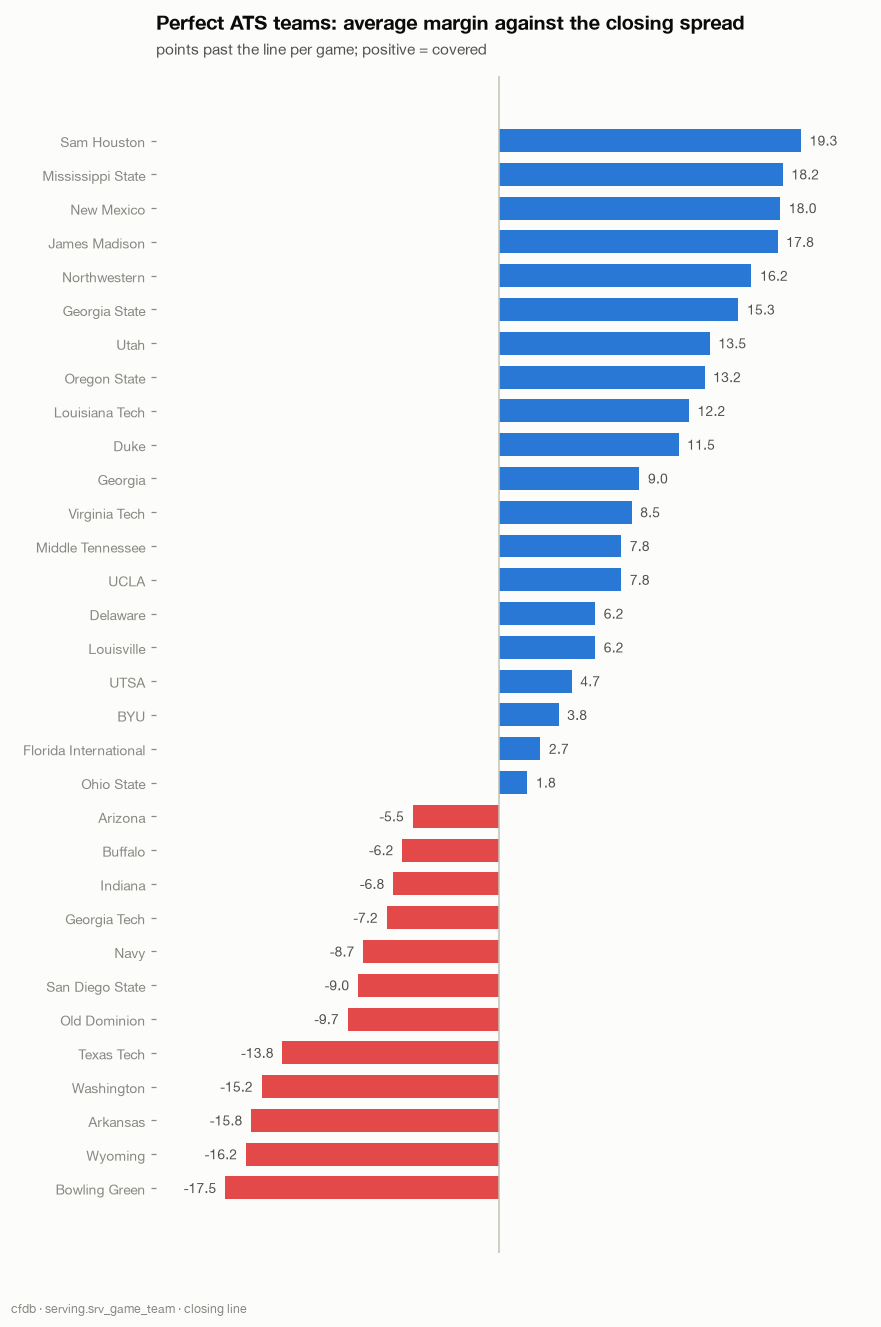

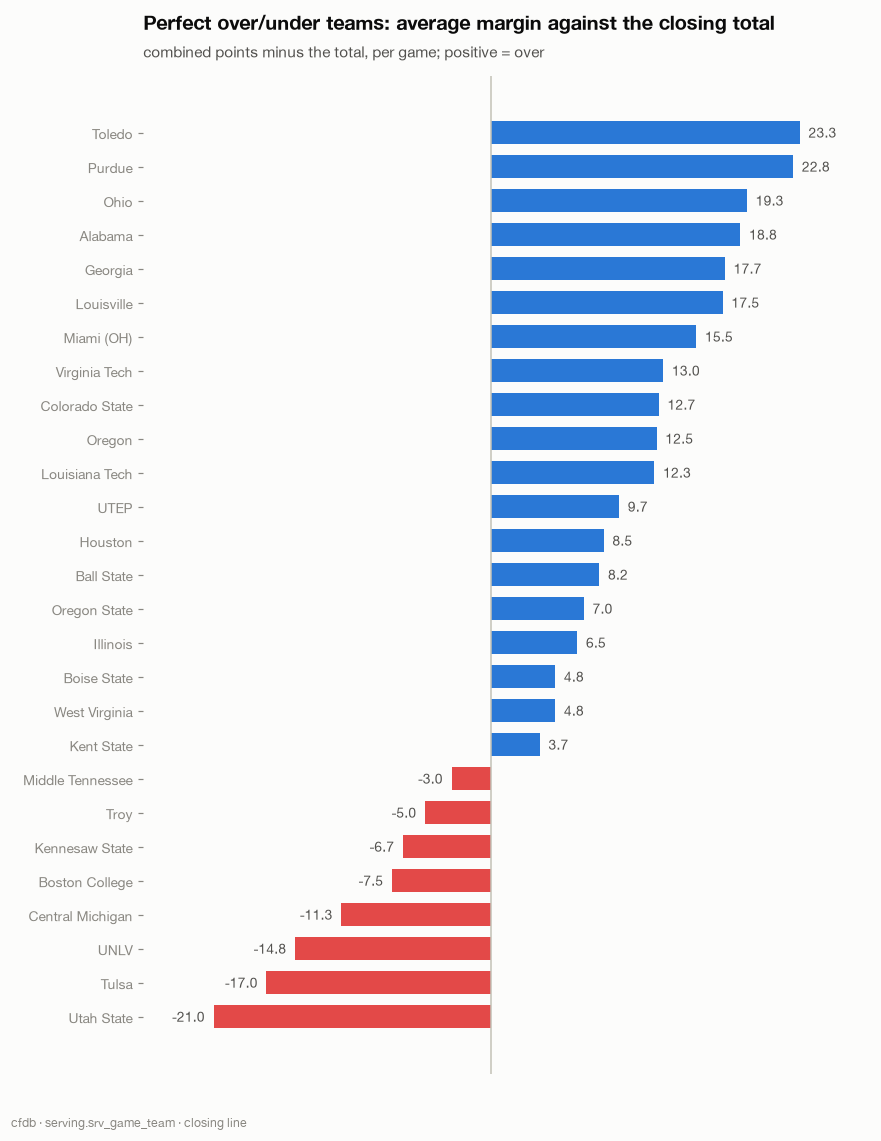

In [10]:
ats = pd.concat([tables["Perfect ATS — covered every game"][0],
                 tables["Perfect ATS — failed to cover every game"][0]])
if len(ats):
    fig, ax = viz.bar(ats, "team", "avg_margin", diverging=True,
                      title="Perfect ATS teams: average margin against the closing spread",
                      subtitle="points past the line per game; positive = covered",
                      source="cfdb · serving.srv_game_team · closing line")

ou = pd.concat([tables["Every game went OVER"][0], tables["Every game went UNDER"][0]])
if len(ou):
    fig, ax = viz.bar(ou, "team", "avg_margin", diverging=True,
                      title="Perfect over/under teams: average margin against the closing total",
                      subtitle="combined points minus the total, per game; positive = over",
                      source="cfdb · serving.srv_game_team · closing line")

### How many would luck alone produce?

Three games is a small sample. If every game were a coin flip against the line, a team with three
graded games would be perfect one way **one time in eight**. So across ~138 teams a healthy crop of
"perfect" teams is expected **with no real edge at all**. The comparison below is the honest way to
read the tables: counts near the coin-flip figure say the tables are mostly luck so far; a count far
above it would say something systematic is going on.

For totals the coin is weighted by how often games actually went over this season.

In [11]:
per_team = games.groupby("team").size()
by_game = games.drop_duplicates("game_id")
p_over = (by_game["total_margin"] > 0).mean()
chance = {
    "Perfect ATS — covered every game":        sum(0.5 ** n for n in per_team),
    "Perfect ATS — failed to cover every game": sum(0.5 ** n for n in per_team),
    "Every game went OVER":                     sum(p_over ** n for n in per_team),
    "Every game went UNDER":                    sum((1 - p_over) ** n for n in per_team),
}
print(f"graded games per team: {per_team.value_counts().sort_index().to_dict()}")
print(f"games that went over this season: {p_over:.1%} of {len(by_game)}\n")
display(pd.DataFrame({"table": list(chance),
                      "teams listed": [len(tables[n][0]) for n in chance],
                      "expected by chance": [round(v, 1) for v in chance.values()]}))

graded games per team: {2: 1, 3: 122, 4: 15}
games that went over this season: 54.5% of 266



,table,teams listed,expected by chance
0,Perfect ATS — covered every game,20,16.4
1,Perfect ATS — failed to cover every game,12,16.4
2,Every game went OVER,19,21.4
3,Every game went UNDER,8,12.3


## 3 · Checks on the tables

**Negative test.** Every team with a mixed record in a category — at least one game each way —
must be absent from that category's tables, both the perfect list and the push block. And the
converse: every team listed must have zero games the other way.

In [12]:
for name, (verdict, target, opposite, margin) in CATEGORIES.items():
    g = grade(games, verdict, target, opposite, margin)
    mixed = set(g.loc[(g["hits"] > 0) & (g["misses"] > 0), "team"])
    listed = set(tables[name][0]["team"]) | set(tables[name][1]["team"])
    assert not (mixed & listed), (name, mixed & listed)
    assert (g.set_index("team").loc[sorted(listed), "misses"] == 0).all(), name
    print(f"{name:<44} listed {len(listed):>3} · mixed-record teams {len(mixed):>3} · overlap 0")

example = grade(games, *CATEGORIES["Perfect ATS — covered every game"])
example = example[(example["hits"] > 0) & (example["misses"] > 0)].sort_values("graded_games").iloc[-1]
print(f"\ne.g. {example['team']} is {example['record']} ATS (covers-misses-pushes) and appears in no ATS table.")

Perfect ATS — covered every game             listed  21 · mixed-record teams 105 · overlap 0
Perfect ATS — failed to cover every game     listed  12 · mixed-record teams 105 · overlap 0
Every game went OVER                         listed  20 · mixed-record teams 110 · overlap 0


Every game went UNDER                        listed   8 · mixed-record teams 110 · overlap 0

e.g. UAB is 2-1-1 ATS (covers-misses-pushes) and appears in no ATS table.


**Hand check.** The raw rows behind one perfect ATS team and one perfect over/under team, so the
tables can be recomputed by eye.

In [13]:
RAW = ["team", "week", "opponent", "site", "points_for", "points_against", "margin",
       "spread_final", "ats_margin_final", "covered_final", "total_final", "combined_points",
       "ou_result", "total_margin"]

for name in ("Perfect ATS — covered every game", "Every game went OVER"):
    main = tables[name][0]
    if len(main):
        team = main.iloc[0]["team"]
        display(Markdown(f"**{team}** — top of *{name}*"))
        display(games.loc[games["team"] == team, RAW])

**Sam Houston** — top of *Perfect ATS — covered every game*

,team,week,opponent,site,points_for,points_against,margin,spread_final,ats_margin_final,covered_final,total_final,combined_points,ou_result,total_margin
298,Sam Houston,1,Troy,away,21,24,-3,16.5,13.5,yes,53.0,45,under,-8.0
299,Sam Houston,2,Tulsa,home,17,23,-6,12.5,6.5,yes,52.0,40,under,-12.0
300,Sam Houston,3,Nicholls,home,59,0,59,-21.0,38.0,yes,51.5,59,over,7.5


**Toledo** — top of *Every game went OVER*

,team,week,opponent,site,points_for,points_against,margin,spread_final,ats_margin_final,covered_final,total_final,combined_points,ou_result,total_margin
348,Toledo,1,Michigan State,away,20,30,-10,10.5,0.5,yes,48.5,50,over,1.5
349,Toledo,2,Central Connecticut,home,63,10,53,-35.5,17.5,yes,53.0,73,over,20.0
350,Toledo,3,Temple,home,49,48,1,-5.0,-4.0,no,48.5,97,over,48.5


## 4 · The game logs

One section for every team that appears in any table above, push blocks included. Games are in
week order through the latest completed game. The spread is **from that team's side** (−7 = the
team gave seven). A game with no line would show blank line columns.

In [14]:
membership = {}
for name in CATEGORIES:
    for label, frame in (("", tables[name][0]), (" (except pushes)", tables[name][1])):
        for team in frame["team"]:
            membership.setdefault(team, []).append(name + label)

LOG = {"week": "week", "game_date": "date", "opponent": "opponent", "site": "site",
       "score": "score", "result": "W/L", "spread_final": "spread", "ats_margin_final": "ATS margin",
       "covered_final": "covered", "total_final": "total", "combined_points": "combined",
       "ou_result": "O/U", "total_margin": "total margin"}

print(f"{len(membership)} teams appear in at least one table.\n")
for team in sorted(membership):
    log = games[games["team"] == team].sort_values(["week", "game_date"]).copy()
    log["score"] = log["points_for"].astype(str) + "-" + log["points_against"].astype(str)
    log = log[list(LOG)].rename(columns=LOG)
    for col in ("spread", "ATS margin", "total", "total margin"):
        log[col] = log[col].map(lambda v: "" if pd.isna(v) else f"{v:+g}" if col != "total" else f"{v:g}")
    log = log.fillna("")
    conf = games.loc[games["team"] == team, "conference"].iloc[0]
    display(Markdown(f"### {team} · {conf}\n\nIn: " + " · ".join(membership[team])))
    display(log.reset_index(drop=True))

54 teams appear in at least one table.



### Alabama · SEC

In: Every game went OVER

,week,date,opponent,site,score,W/L,spread,ATS margin,covered,total,combined,O/U,total margin
0,1,2026-09-05,East Carolina,home,48-10,W,-28,+10,yes,52.5,58,over,+5.5
1,2,2026-09-12,Kentucky,away,45-17,W,-8.5,+19.5,yes,47,62,over,+15
2,3,2026-09-19,Florida State,home,50-36,W,-19.5,-5.5,no,50,86,over,+36


### Arizona · Big 12

In: Perfect ATS — failed to cover every game

,week,date,opponent,site,score,W/L,spread,ATS margin,covered,total,combined,O/U,total margin
0,1,2026-09-05,Northern Arizona,home,35-7,W,-31.5,-3.5,no,58.5,42,under,-16.5
1,2,2026-09-12,BYU,away,17-28,L,+7,-4,no,49,45,under,-4
2,3,2026-09-19,Northern Illinois,home,42-17,W,-34,-9,no,50,59,over,+9


...

,week,date,opponent,site,score,W/L,spread,ATS margin,covered,total,combined,O/U,total margin
0,1,2026-09-06,Washington State,home,24-10,W,-23,-9,no,51,34,under,-17
1,2,2026-09-12,Utah State,home,16-14,W,-28,-26,no,55.5,30,under,-25.5
2,3,2026-09-19,Eastern Washington,home,48-16,W,-42.5,-10.5,no,58.5,64,over,+5.5


### West Virginia · Big 12

In: Every game went OVER

,week,date,opponent,site,score,W/L,spread,ATS margin,covered,total,combined,O/U,total margin
0,1,2026-09-05,Coastal Carolina,home,31-24,W,-21,-14,no,54.5,55,over,+0.5
1,2,2026-09-12,UT Martin,home,52-7,W,-41.5,+3.5,yes,56.5,59,over,+2.5
2,3,2026-09-19,Virginia,neutral,38-27,W,+11,+22,yes,53.5,65,over,+11.5


### Wyoming · Mountain West

In: Perfect ATS — failed to cover every game

,week,date,opponent,site,score,W/L,spread,ATS margin,covered,total,combined,O/U,total margin
0,1,2026-09-05,Colorado State,away,13-35,L,+3,-19,no,46.5,48,over,+1.5
1,2,2026-09-12,Northern Colorado,home,21-13,W,-22.5,-14.5,no,44,34,under,-10
2,3,2026-09-19,Central Michigan,away,10-24,L,-1,-15,no,40,34,under,-6
